In [2]:
# =========================
# Model 3: Improved CNN Image-Based Regression
# Improvements:
# 1. Use more images
# 2. Scale target tensor labels
# 3. Use early stopping
# 4. Use a simpler CNN to reduce overfitting
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
folder = r"C:\Users\pkwki\Downloads\Fiber dataBase\images_try"

In [4]:
rows = []

for file in os.listdir(folder):
    if file.endswith(".jpg"):
        name = file.replace(".jpg", "")
        axx, ayy, azz = map(float, name.split(","))

        rows.append({
            "image_file": file,
            "a_xx": axx,
            "a_yy": ayy,
            "a_zz": azz
        })

df_img = pd.DataFrame(rows)

print(df_img.shape)
print(df_img.head())

(55092, 4)
                 image_file    a_xx    a_yy    a_zz
0  0.0003,0.9969,0.0028.jpg  0.0003  0.9969  0.0028
1  0.0003,0.9970,0.0026.jpg  0.0003  0.9970  0.0026
2  0.0003,0.9970,0.0027.jpg  0.0003  0.9970  0.0027
3  0.0003,0.9972,0.0025.jpg  0.0003  0.9972  0.0025
4  0.0003,0.9973,0.0023.jpg  0.0003  0.9973  0.0023


In [5]:
IMG_SIZE = 64

X_img = []
y_img = []

for _, row in df_img.iterrows():
    img_path = os.path.join(folder, row["image_file"])

    img = imread(img_path, as_gray=True)
    img = resize(img, (IMG_SIZE, IMG_SIZE))

    X_img.append(img)
    y_img.append([row["a_xx"], row["a_yy"], row["a_zz"]])

X_img = np.array(X_img, dtype=np.float32)
y_img = np.array(y_img, dtype=np.float32)

X_img = X_img.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("X shape:", X_img.shape)
print("y shape:", y_img.shape)

X shape: (55092, 64, 64, 1)
y shape: (55092, 3)


In [6]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_img,
    y_img,
    test_size=0.2,
    random_state=42
)

In [7]:
y_scaler = StandardScaler()

y_train3_scaled = y_scaler.fit_transform(y_train3)
y_test3_scaled = y_scaler.transform(y_test3)

In [8]:
model3 = Sequential([
    Conv2D(16, (3,3), activation="relu", padding="same",
           input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPool2D((2,2)),

    Conv2D(32, (3,3), activation="relu", padding="same"),
    MaxPool2D((2,2)),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    MaxPool2D((2,2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(3, activation="linear")
])

model3.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model3.summary()

C:\Users\pkwki\anaconda3\envs\ti64ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         262,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 285,699 (1.09 MB)

 Trainable params: 285,699 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

hist3 = model3.fit(
    X_train3,
    y_train3_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_test3, y_test3_scaled),
    callbacks=[early_stop]
)

Epoch 1/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.1555 - mae: 0.2483 - val_loss: 0.0456 - val_mae: 0.1360
Epoch 2/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0751 - mae: 0.1865 - val_loss: 0.0180 - val_mae: 0.0852
Epoch 3/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0629 - mae: 0.1704 - val_loss: 0.0204 - val_mae: 0.0860
Epoch 4/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0579 - mae: 0.1643 - val_loss: 0.0223 - val_mae: 0.1080
Epoch 5/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0543 - mae: 0.1583 - val_loss: 0.0144 - val_mae: 0.0845
Epoch 6/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0534 - mae: 0.1579 - val_loss: 0.0128 - val_mae: 0.0734
Epoch 7/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0522 - mae: 0.1557 - val_loss: 0.0198 - val_mae: 0.0974
Epoch 8/100
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0510 - mae: 0.1527 - val_loss: 0.0152 - val_mae: 0.0773
Epoch 9/100
1378/1378 ━━

In [10]:
pred3_scaled = model3.predict(X_test3)

pred3 = y_scaler.inverse_transform(pred3_scaled)

r2_3 = r2_score(y_test3, pred3)
mae_3 = mean_absolute_error(y_test3, pred3)

print("Model 3 CNN R2:", r2_3)
print("Model 3 CNN MAE:", mae_3)

345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Model 3 CNN R2: 0.9904305934906006
Model 3 CNN MAE: 0.011649067513644695


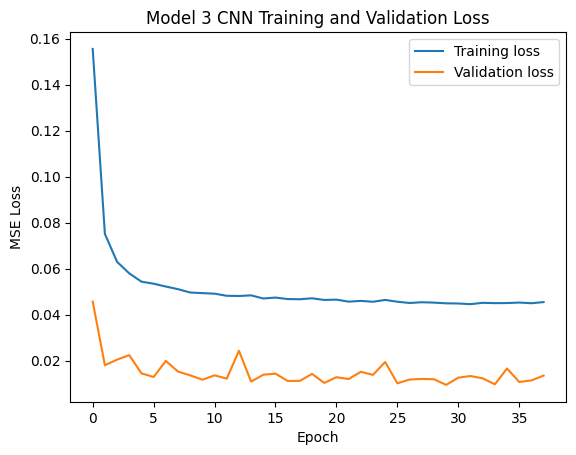

In [11]:
plt.plot(hist3.history["loss"], label="Training loss")
plt.plot(hist3.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Model 3 CNN Training and Validation Loss")
plt.legend()
plt.show()

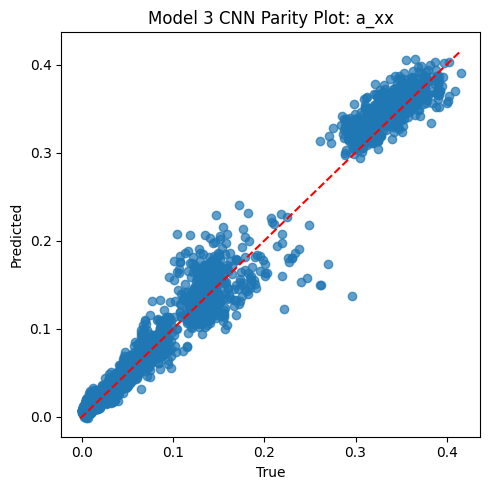

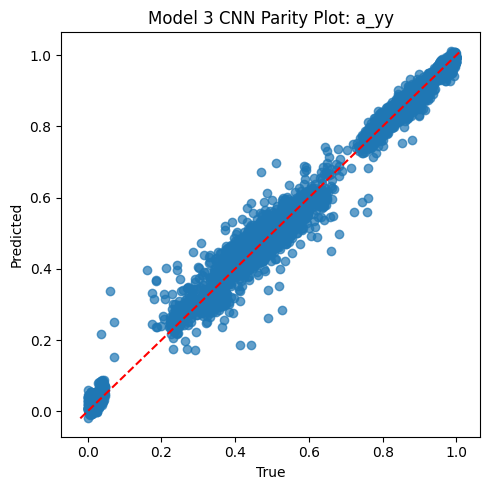

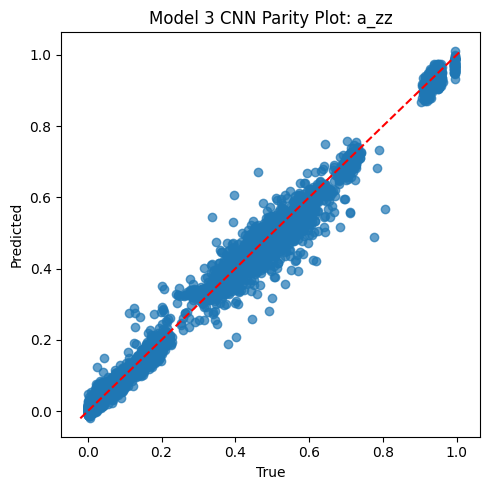

In [12]:
labels = ["a_xx", "a_yy", "a_zz"]

for i in range(3):
    plt.figure(figsize=(5,5))

    plt.scatter(y_test3[:, i], pred3[:, i], alpha=0.7)

    min_val = min(y_test3[:, i].min(), pred3[:, i].min())
    max_val = max(y_test3[:, i].max(), pred3[:, i].max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--")

    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Model 3 CNN Parity Plot: {labels[i]}")

    plt.tight_layout()
    plt.show()

In [13]:
print("Model 3 R2:", r2_3)
print("Model 3 MAE:", mae_3)

Model 3 R2: 0.9904305934906006
Model 3 MAE: 0.011649067513644695


In [14]:
# Save trained CNN model
model3.save("model3_cnn_tensor.keras")

# Save scaler
import joblib
joblib.dump(y_scaler, "model3_y_scaler.pkl")

['model3_y_scaler.pkl']